Datasets are highly susceptible to noisy, missing, and inconsistent data due to their typically huge size
and their likely origin from multiple, heterogeneous sources. Low-quality data will lead to low-quality
mining results. Huge efforts need to be paid to preprocess the data to enhance the quality of data for
effective mining, and transform it to more efficient features, and find patterns in it.

There are many factors com-
prising data quality, including **accuracy, completeness, consistency, timeliness, believability, and interpretability**.

Data preprocessing has 4 phases:
- Data cleaning
- Data integration (if necessary)
- Data transformation
- Data selection

We will back to our previous problem: Titanic dataset

> <center>"I'm not a genius, but I'm flexible enough to see when the data shows me something different than what I think it should tell me."</center>

In [2]:
!pip install -q pyod cleanlab

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.7/364.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 18.4 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from sklearn.naive_bayes  import MultinomialNB
from sklearn.linear_model import LinearRegression
from sklearn.feature_extraction import DictVectorizer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.neighbors import NearestNeighbors

In [5]:
!wget -q --no-check-certificate 'https://docs.google.com/uc?export=download&id=1jpaNUBQ2ehkIB8nNP1XxyJjNtpCdvkTL' -O "data.zip"
!unzip -q "data.zip"

In [109]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
df = pd.concat([train_df, test_df]).reset_index().drop(['index'], axis=1)
df = df.astype({'Pclass': 'category', 'Sex': 'category', 'Embarked': 'category'}) # why not 'Survived': 'bool'?
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [44]:
df.dtypes

,0
PassengerId,int64
Survived,float64
Pclass,category
Name,object
Sex,category
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [77]:
df.describe()

,PassengerId,Survived,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,80.000000,8.000000,9.000000,512.329200


In [8]:
df.describe(include=['object', 'category'])

,Pclass,Name,Sex,Ticket,Cabin,Embarked
count,1309,1309,1309,1309,295,1307
unique,3,1307,2,929,186,3
top,3,"Kelly, Mr. James",male,CA. 2343,C23 C25 C27,S
freq,709,2,843,11,6,914


# Data Cleaning
- Handle missing values
- Smooth noise and correct inconsistencies
- Detect outliers
- Remove duplicates

## Missing values

We remember that our data contains null values in age, fare, cabin, survived, and embarked attributes.

We can handle or fill missing values in these attributes by one of he following methods:

1. delete all rows with missing values:

This is usually done when the class label is missing (assuming the mining task
involves classification). This method is not very effective, unless the row contains several attributes
with missing values. It is especially poor when the percentage of missing values per attribute varies
considerably. By ignoring the tuple, we do not make use of the remaining attributes’ values in the
rows.

We can drop rows with missing values in pandas by dropna function which take the parameter `how` that determine if row (or column if axis set to 1) is removed from DataFrame, when we have at least one NA or all NA, it takes tha values:

- `any` : If any NA values are present, drop that row or column.

- `all` : If all values are NA, drop that row or column.

default is ‘any’.

In [ ]:
temp = df.dropna()
temp.isnull().sum()

index          0
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [ ]:
temp.shape

(183, 13)

We can also set column label to check the missing values in it only




In [19]:
temp = df.dropna(subset='Survived')
temp.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,263
SibSp,0
Parch,0
Ticket,0
Fare,1


2. Fill in the missing value manually: In general, this approach is time consuming and may not be
feasible given a large data set with many missing values.
3. Use a global constant to fill in the missing value: Replace all missing attribute values by the same
constant such as a label like “Unknown” or −∞.

  **Problem**:

  The mining program may mistakenly think that they form an interesting concept, since they all have a value in common that of “Unknown”. Hence, although this method is simple, it is not
  foolproof.

  When this method is useful?

  Assume that we have the case: when applying for a credit card, candidates may be asked to supply their driver’s license number. Candidates who do not have a driver’s license may naturally leave this field blank, these blank values can be filled with “not applicable” constant.

4. Use a measure of central tendency for the attribute (e.g., the mean or median) to fill in the missing value.

  For normal (symmetric) data distributions, the mean can be used, whereas
skewed data distribution should employ the median.

In [78]:
mean = df['Age'].mean()
print(f'Age Average: {mean}')
df['Age'].fillna(value=mean)

Age Average: 29.881137667304014


,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
1304,29.881138
1305,39.000000
1306,38.500000
1307,29.881138


In [11]:
top_freq_value = df['Embarked'].mode()
print(f'Most Frequent Embarked value: {top_freq_value}')
df['Embarked'].fillna(value=top_freq_value)

Most Frequent Embarked value: 0    S
Name: Embarked, dtype: category
Categories (3, object): ['C', 'Q', 'S']


,Embarked
0,S
1,C
2,S
3,S
4,S
...,...
1304,S
1305,C
1306,S
1307,S


**Problem**:

Is the central tendency measure sufficient to replace missing values in attribute with values following the below distribution?

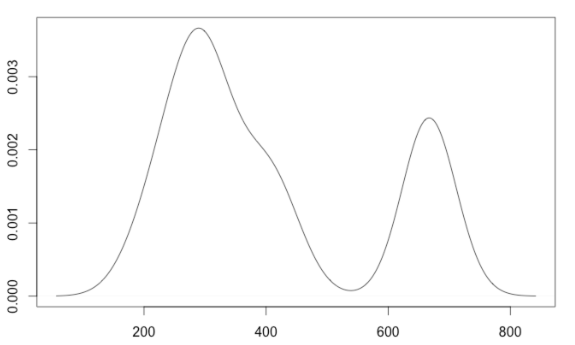





5. Use the attribute mean or median for all samples belonging to the same class as the given row.



In [46]:
survived_ages_avg = df[['Age', 'Survived']].groupby(['Survived']).mean()
survived_ages_avg

,Age
Survived,
0.0,30.626179
1.0,28.343690


In [13]:
for i in survived_ages_avg.index:
  df[df['Survived'] == i]['Age'].fillna(survived_ages_avg.loc[i]["Age"])

Rather than the label class (here is survived) we can think in smarter way by searching for the attributes that correlated with the column with missing values, and use this relation to estimate the missing values.

Let's use the relations we found in previous lecture by EDA:

In embarked column we saw 2 missing values, let's see what are those two null values:

In [47]:
df[df.Embarked.isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1.0,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1.0,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


Both passengers are female and  paid a fare of 80$ for 1st class in cabin B28. Let's see how the Fare is distributed among all Pclass and Embarked feature values:

In [128]:
layout_options = {
    'paper_bgcolor':"#383838",
    'plot_bgcolor':'#383838',
    'title_font': dict(color='white'),
    'legend_font': dict(color='white'),
    'yaxis':dict(color="white"),
    'xaxis':dict(color="white")
    }

In [ ]:
fig = px.box(df, x='Embarked', y="Fare", color='Pclass')
fig.update_layout(**layout_options)
fig.show()

In the same way, we can see how the fare is distributed among all cabins and embarked feature values, but cabin has alot of missing values and we saw the all passengers in B cabins are from 1st class, therefore, we can depend on pclass only.

Fare median closest to 80 in the C Embarked values where pclass is 1. So, let's fill in the missing values as "C"

In [ ]:
df['Embarked'].fillna(value='C', inplace=True)

For fill missing values in age column, Let's see if we can use title in name field to predict the age:

In [114]:
df['Name'] = df['Name'].str.extract(r', ([A-Za-z]+)\.')
df['Name']

,Name
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr
...,...
1304,Mr
1305,Dona
1306,Mr
1307,Mr


In [23]:
df['Name'].value_counts()

,count
Name,
Mr,757
Miss,260
Mrs,197
Master,61
Rev,8
Dr,8
Col,4
Major,2
Ms,2


Since some titles are rare (ex. Don, Jonkheer, ...), we can git ride of them, but first let's see if the related row have missing values in age columns:

In [115]:
df[~df['Name'].isin(['Mr', 'Miss', 'Mrs', 'Master'])]['Age'].isnull().sum()

np.int64(2)

In [80]:
df[(~df['Name'].isin(['Mr', 'Miss', 'Mrs', 'Master'])) & (df.Age.isnull())]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
766,767,0.0,1,Dr,male,NaN,0,0,112379,39.60,NaN,C
979,980,NaN,3,Ms,female,NaN,0,0,364856,7.75,NaN,Q


There is inconsistency in 'MS' title, let's replace these tilels with appropriate titles form the most common ones:

In [119]:
df['Name'].replace({'Ms': 'Miss', 'Dr': 'Mr'}, inplace=True)

In [120]:
pivot_table = df[df['Name'].isin(['Mr', 'Miss', 'Mrs', 'Master'])].pivot_table(index='Name', columns='Survived', values='Age', aggfunc=["median"])
pivot_table

median      
Survived    0.0   1.0
Name                 
Master      4.0   3.0
Miss       22.0  22.0
Mr         29.0  29.0
Mrs        35.5  35.5

In [61]:
pivot_table.columns

MultiIndex([('median', 0.0),
            ('median', 1.0)],
           names=[None, 'Survived'])

In [62]:
pivot_table.loc['Master', ('median', 0.0)]

np.float64(4.0)

In [94]:
pivot_table.columns = [0.0, 1.0]

In [84]:
pivot_table.columns

Index([0.0, 1.0], dtype='float64')

In [108]:
df.Survived.isnull().sum()

np.int64(418)

In [103]:
for col in pivot_table.columns:
  for title in pivot_table.index:
    df.loc[(df['Name'] == title) & (df['Survived'] == col) & (df['Age'].isnull()), 'Age'] = pivot_table.loc[title, col]

In [104]:
df[df['Age'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
901,902,NaN,3,Mr,male,NaN,0,0,349220,7.8958,NaN,S
913,914,NaN,1,Mrs,female,NaN,0,0,PC 17598,31.6833,NaN,S
920,921,NaN,3,Mr,male,NaN,2,0,2662,21.6792,NaN,C
924,925,NaN,3,Mrs,female,NaN,1,2,W./C. 6607,23.4500,NaN,S
927,928,NaN,3,Miss,female,NaN,0,0,342712,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1299,1300,NaN,3,Miss,female,NaN,0,0,334915,7.7208,NaN,Q
1301,1302,NaN,3,Miss,female,NaN,0,0,365237,7.7500,NaN,Q
1304,1305,NaN,3,Mr,male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1307,1308,NaN,3,Mr,male,NaN,0,0,359309,8.0500,NaN,S


Because survived in the previous rows are missing too.

For these rows we can depend on titles only, or remove them:

In [121]:
median_ages_dict = df[df['Name'].isin(['Mr', 'Miss', 'Mrs', 'Master'])].groupby('Name')['Age'].median().to_dict()
median_ages_dict

{'Master': 4.0, 'Miss': 22.0, 'Mr': 29.0, 'Mrs': 35.5}

In [ ]:
df['Age'].fillna(df["Name"].map(median_ages_dict), inplace=True)

In [123]:
df['Age'].isnull().sum()

np.int64(0)

Is that right?

Important: make sure not to use any dependent variable (survived here) to predict missing values of the features. Why?

In fare there is only one missing value:

In [124]:
df[df.Fare.isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1043,1044,NaN,3,Mr,male,60.5,0,0,3701,NaN,NaN,S


In [ ]:
df['Fare'].fillna(df[df['Pclass'] == 3]['Fare'].mean(), inplace=True)

For fill the missing values in cabin column, approximately 77% of Cabin feature is missing. We have two choices,

- we can either get rid of the whole feature.
- we can brainstorm a little and find an appropriate way to put them in use.

We saw previously relation between cabins and passenger class, but passengers from particular class are distributed on multiple cabins, so mabye we can not get benefit a lot form pclass values. again we saw that fare and classes are correlated. Let's use the fare values to estimate the cabin missing values:

In [126]:
df['Cabin'] = df['Cabin'].fillna(value='N').str.slice(0, 1)
df['Cabin']

,Cabin
0,N
1,C
2,N
3,C
4,N
...,...
1304,N
1305,C
1306,N
1307,N


In [129]:
fig = px.box(df, x='Cabin', y="Fare")
fig.update_layout(**layout_options)
fig.show()

There is an overlap between some cabins fare, let's us use the pclass too:

In [ ]:
fig = px.box(df[(df['Cabin'] != 'N') & (df['Fare'] < 400)], x='Cabin', y="Fare", color='Pclass')
fig.update_layout(**layout_options)
fig.show()

In [130]:
def cabin_fillna(fare, pclass):
  if pclass == 3:
    if fare > 7 and fare <= 8:
      return 'F'
    elif fare >= 10 and fare <= 17:
      return 'G'
    elif fare < 10:
      return 'E'
    else:
      return 'F'
  if pclass == 2:
    return 'F'
  if pclass == 1:
    if fare < 35:
      return 'A'
    elif fare >= 30 and fare < 80:
      return 'D'
    elif (fare >= 80 and fare < 120 )or fare > 400:
      return 'B'
    elif fare >= 120 and fare < 270:
      return 'C'
    else:
      return 'A'

In [131]:
values = df[df['Cabin'] == 'N'].apply(lambda x: cabin_fillna(x['Fare'], x['Pclass']), axis=1)
values

,0
0,F
2,F
4,E
5,E
7,F
...,...
1303,F
1304,E
1306,F
1307,E


In [132]:
values.isnull().sum()

np.int64(0)

Instead of writing all these conditions that may be  not accurate, we can do:

5. Use the most probable value to fill in the missing value: This may be determined with regression, inference-based tools using a Bayesian formalism or decision tree induction.

  It is a popular strategy. In comparison to the other methods, it uses the most information from the present data to predict missing values. By considering the values of other attributes in its estimation of the missing values, there is a greater chance that the relationships between income and the other attributes are preserved.

Let's use naive bayes model.

Remember Naive Bayes Model?

Naive Bayes: is a linear Bayesian classifier, called naive because it makes a simplifying (naive) assumption about how the features interact, and bayes beacuse it depends on bayes rule.<br>

Bayes’ rule:
\begin{align}
P(y|x) = P(x|y)P(y) /P(x)
\end{align}

Best class y* is:
\begin{align}
y^* = argmax_y P(x|y)P(y) /P(x)
\end{align}

But P(x) doesn’t change for each class; we are always asking about the most likely class for the same point x, which must have the same probability P(x). Thus, we can choose the class that maximizes this simpler formula:
\begin{align}
y^* = argmax_y P(x|y)P(y)
\end{align}

where the **prior** probability of the class P(y) and the **likelihood** of the word P(x|y) which means "if we were going to generate a class y, how likely is that this feature would be x".<br>
In most datasets, an observation $x$ is represented by a set of multiple features f1 , f2 , ..., fn:

\begin{align}
y^* = argmax P( f_1 , f_2 , ...., f_n |y) p(y)
\end{align}

This is the conditional Calculating the joint probability of all features together is computationally expensive and requires massive amounts of data.

**naive Bayes assumption**: To solve this, we make the Naive Bayes Assumption: we assume that all features are conditionally independent given the class $y$.

the class y and hence can be **‘naively’** multiplied as follows
\begin{align}
P( f_1 , f_2 , ...., f_n |y) = P( f_1 |y) · P( f_2 |y) · ... · P( f_n |y)
\end{align}

\begin{align}
y^* = argmax_y P(y) . \prod_{fi\in F} p(f_i|y)
\end{align}


**Training**:<br>
- $P(y)$: We calculate the fraction of the total samples that belong to class $y$.
- $P(f_i|y)$: We compute the frequency of feature $f_i$ appearing within all samples of class $y$.

Note: While the independence assumption is rarely 100% accurate in real-world data (features often correlate), Naive Bayes remains remarkably effective for many classification tasks.<br>

**Remember**:
Independence assumption is not accurate in all cases.

In [133]:
pd.get_dummies(df[df['Cabin'] != 'N'][['Fare', 'Pclass', 'Embarked']], dtype=int)

,Fare,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S
1,71.2833,1,0,0,1,0,0
3,53.1000,1,0,0,0,0,1
6,51.8625,1,0,0,0,0,1
10,16.7000,0,0,1,0,0,1
11,26.5500,1,0,0,0,0,1
...,...,...,...,...,...,...,...
1295,27.7208,1,0,0,1,0,0
1296,13.8625,0,1,0,1,0,0
1298,211.5000,1,0,0,1,0,0
1302,90.0000,1,0,0,0,1,0


In [ ]:
X = pd.get_dummies(df[df['Cabin'] != 'N'][['Fare', 'Pclass', 'Embarked']], dtype=int).values
encoder = LabelEncoder()
y = encoder.fit_transform(df[df['Cabin'] != 'N']['Cabin'])
y

array([2, 2, 4, 6, 2, 3, 0, 2, 1, 3, 1, 2, 1, 2, 5, 5, 2, 4, 0, 3, 3, 2,
       1, 4, 3, 5, 3, 2, 1, 5, 2, 4, 1, 0, 2, 5, 0, 5, 1, 1, 6, 0, 3, 3,
       2, 2, 2, 3, 6, 2, 1, 4, 1, 2, 2, 2, 3, 0, 1, 3, 2, 2, 1, 4, 2, 2,
       4, 2, 1, 2, 4, 2, 3, 1, 2, 2, 2, 4, 7, 5, 2, 5, 2, 4, 3, 1, 4, 2,
       1, 3, 6, 2, 4, 2, 4, 1, 2, 0, 2, 2, 2, 4, 3, 4, 4, 3, 0, 1, 2, 1,
       2, 3, 2, 1, 2, 4, 3, 5, 1, 1, 2, 1, 1, 1, 2, 2, 0, 4, 2, 4, 4, 2,
       0, 4, 1, 3, 0, 2, 5, 3, 3, 3, 0, 1, 1, 3, 0, 3, 4, 2, 1, 1, 3, 1,
       1, 2, 5, 2, 4, 4, 2, 2, 2, 5, 2, 4, 4, 1, 1, 3, 2, 1, 1, 3, 4, 1,
       1, 3, 4, 5, 1, 1, 3, 1, 3, 1, 0, 4, 1, 1, 4, 1, 4, 2, 2, 3, 4, 3,
       0, 3, 1, 2, 1, 2, 1, 4, 1, 1, 0, 2, 3, 3, 0, 3, 2, 2, 5, 1, 1, 2,
       2, 3, 2, 2, 2, 2, 1, 2, 2, 5, 0, 2, 6, 2, 2, 2, 1, 4, 2, 2, 3, 1,
       2, 5, 4, 4, 3, 1, 4, 2, 0, 1, 2, 5, 2, 3, 2, 4, 3, 2, 2, 2, 1, 5,
       0, 3, 1, 2, 1, 2, 1, 5, 5, 5, 0, 2, 1, 3, 4, 2, 4, 4, 1, 0, 2, 1,
       3, 2, 1, 2, 3, 3, 2, 2, 2])

In general:

Use one-hot encoding
- When the categorical feature has no order or is not ordinal. For example, the city where a person is in is not ordinal so one-hot encoding can be used for such types of columns.
- When the number of unique categorical features is less. This is because more features increase the model’s complexity and training time.

Use label encoding
- When the categorical feature has some order or is ordinal. For example, an army’s position is ordinal and the highest position has a high number.
- When the number of categories is large.

In [ ]:
classifier = MultinomialNB()
classifier.fit(X, y)

MultinomialNB()

In [ ]:
rows_with_missing_cabin = pd.get_dummies(df[df['Cabin'] == 'N'][['Fare', 'Pclass', 'Embarked']], dtype=int)
x = rows_with_missing_cabin.values
predictions = classifier.predict(x)

In [ ]:
for i, ind in enumerate(rows_with_missing_cabin.index):
  df.loc[ind, 'Cabin'] = predictions[i]

In [ ]:
df[df['Cabin'] == 'N']['Cabin'].count()

0

Note:
- In some cases, a missing value may not imply an error in the data!

  You need to use any knowledge you may already have regarding properties of the data. Such knowledge or “data about data” is referred to as **metadata**.

- Missing values are not always clear, this type of error called **disguised missing data**. For Example: enter the default values when respondents not wanting to divulge information about themselves, poorly designed data entry forms that have many optional fields.



## Noisy data

Noise is a random error or variance in a measured variable.

Noise often causes the algorithms to miss out on patterns in the data. Noisy data is meaningless data. This terminology has been used as a synonym for corrupt data.

Do you remember when you saw noisy data before?

- In text data: spelling mistakes, typos, slang, abbreviations, or ambiguous expressions, inconsistent labels.

- In speech signals: sounds in the background

- In images: random variation of brightness or color information in images.


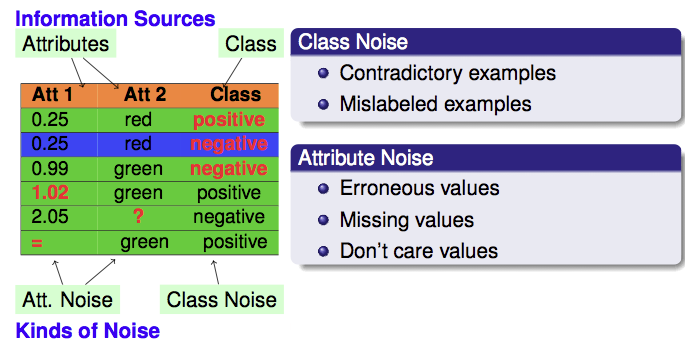

The biggest risk of noisy data is `Overfitting`.

Machine Learning models are designed to find patterns. If your data is noisy, a complex model might think the "noise" is actually a "rule." It will memorize the errors instead of learning the general logic.

**Noise Types**:
- The **class labels noise** represents whether the class of each instances is correctly assigned or not. There are two
possible sources for class noise:
  - **Contradictory instances**: The same instances appear more than once in the data set and are labeled with different class labels.
  - **Mislabeled instances**: Instances are labeled with wrong class label. for example: the following lables inconsistency in images due to lack on annotaion instructions for the labelers.


  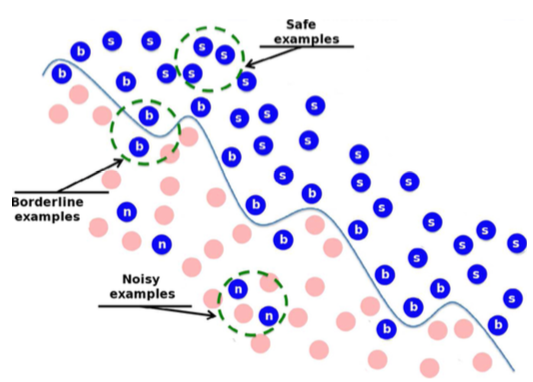

  However recent studies have found that even highly-curated ML benchmark datasets are full of label errors! and real-world datasets can be far lower quality. [check label errors website](https://labelerrors.com/)

  Crowdsourcing is where individuals, known as "workers" or "Turkers," can complete various tasks for a small fee, like lebaling and evaluation.

  The problem with crowdsourcing is that people tend not to complete large data or label samples randomly to finish the labels as quickly as possible in order to get more money.

  It's better to write detailed instructions for annotaion and send feedbacks to the workers every 10-20 examples.


  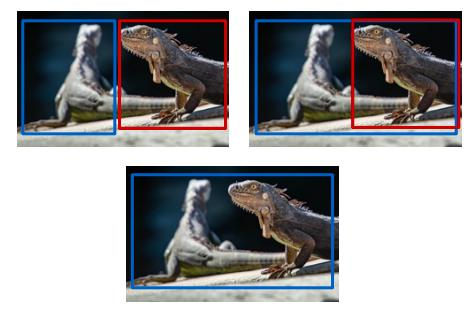


  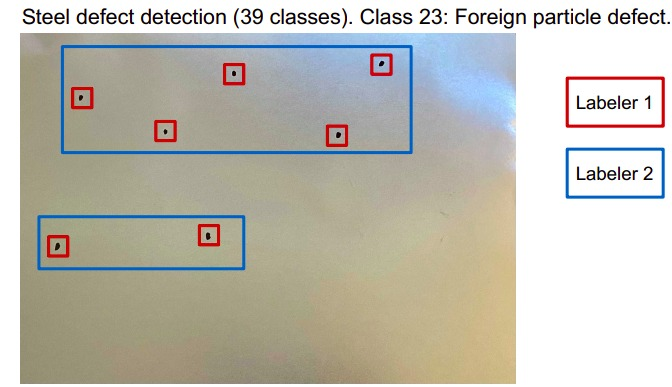

  Another example: lable artifacts by three labelers:

  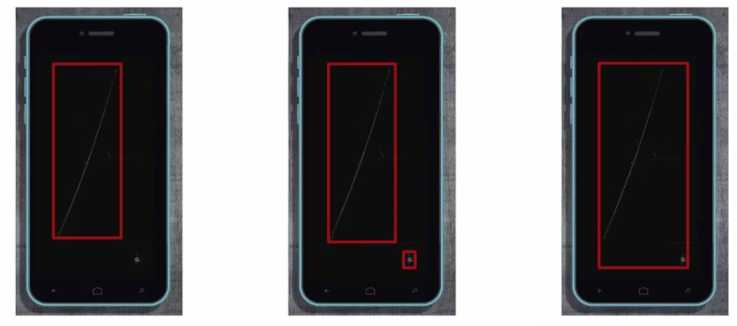

  Transcribe speech audio by three labelers:

  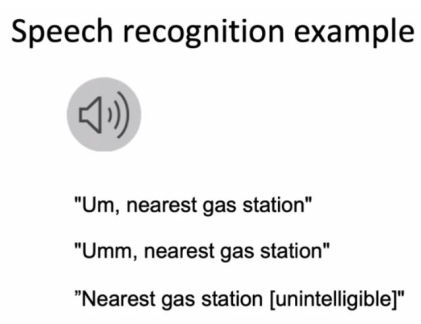
  

- **Attribute noise**: reflects erroneous values for one or more attributes (independent variables)
of the data set. For example:
  - Values out of the all attribute values range (a typo such as “20010” in a year field).
  - Incomplete attributes or "do not care" values

- **Row** or **sample noise**: for example: soft deleted rows, wrong invoice entry.

  It needs external knowledge about the data to discover wrong rows, then delete them.

Noisy data can lead to incorrect predictions, biased models, and misleading insights.

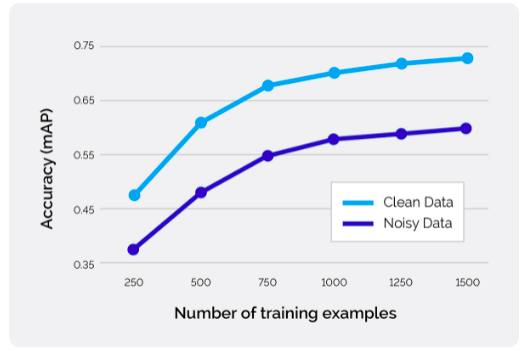


The recent shift toward **data-centric** AI encourages data scientists to spend at least as much time improving their data as they do improving their models. No matter how much you tweak them, the quality of your models will ultimately depend on the quality of the data used to train and evaluate them.


<center>Garbage in ---> Garbage out</center>

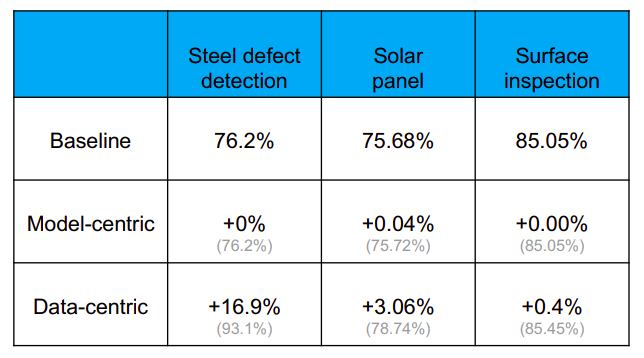


`Real world data is complex, messy, and strange, these is the nature of data that collected by happenstance rather than with purpose. You need to deal with that truth.`

However, large dataset can reduce the effect of noisy sample, and robust strong models can correctly make predictions even with noisy training data, in other hand, noise in the training data helps make the trained model deal with inputs that are not quite like those in the training set of data:

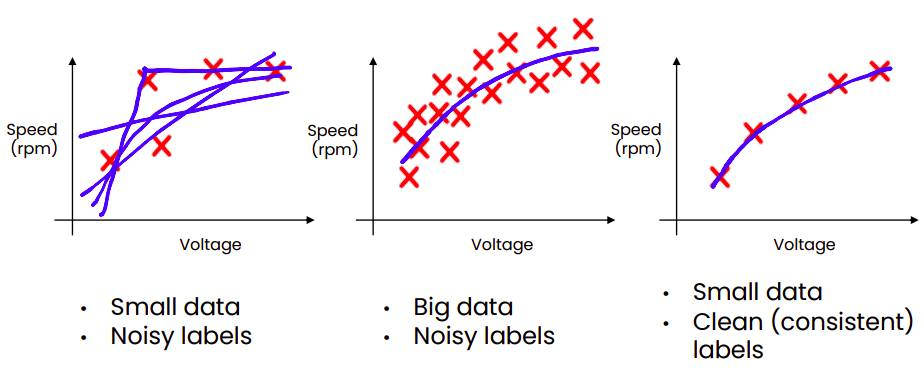

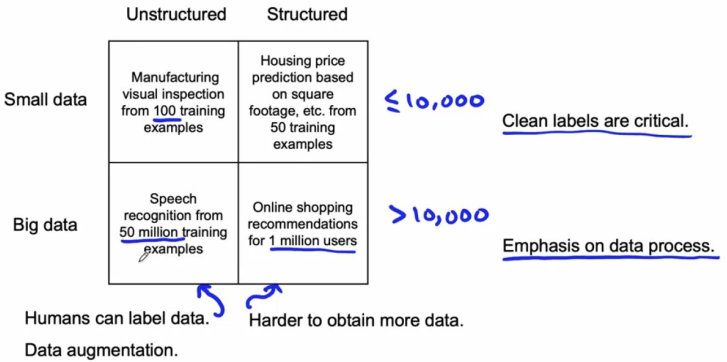



### Fix Noisy Attributes

Let's check if there are any inavlid values according to our knowledge about our data variables values ranges before apply any algorithm:

In [ ]:
df[df['Age'] <= 0]['Age'].count()

0

In [ ]:
df[df['Fare'] < 0]['Fare'].count()

0

- **Binning**: Binning methods smooth a sorted data value by consulting its “neighborhood,” that is, the
values around it. The sorted values are distributed into a number of “buckets,” or bins. Because
binning methods consult the neighborhood of values, they perform local smoothing.

  Smoothing types:
  - Smoothing by bin means: each value in a bin is replaced by the mean value of the bin.

  - Smoothing by bin boundaries: the minimum and maximum values in a given bin are identified as the bin boundaries. Each bin value is then replaced by the closest boundary value.

  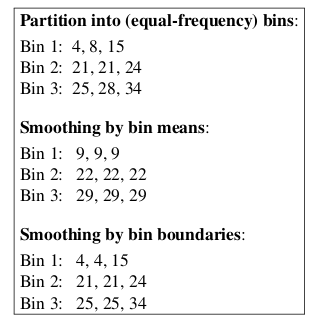

  Note: Binning is also used as a discretization technique a form of data transformation) and data reduction).


Let's show how to smooth fare values in these methods:

In [ ]:
bins = 50
pd.cut(df['Fare'], bins, retbins=True)

(0         (-0.512, 10.247]
 1          (61.48, 71.726]
 2         (-0.512, 10.247]
 3          (51.233, 61.48]
 4         (-0.512, 10.247]
                ...        
 1304      (-0.512, 10.247]
 1305    (102.466, 112.712]
 1306      (-0.512, 10.247]
 1307      (-0.512, 10.247]
 1308       (20.493, 30.74]
 Name: Fare, Length: 1309, dtype: category
 Categories (50, interval[float64, right]): [(-0.512, 10.247] < (10.247, 20.493] < (20.493, 30.74] <
                                             (30.74, 40.986] ... (471.343, 481.589] <
                                             (481.589, 491.836] < (491.836, 502.083] <
                                             (502.083, 512.329]],
 array([ -0.5123292,  10.246584 ,  20.493168 ,  30.739752 ,  40.986336 ,
         51.23292  ,  61.479504 ,  71.726088 ,  81.972672 ,  92.219256 ,
        102.46584  , 112.712424 , 122.959008 , 133.205592 , 143.452176 ,
        153.69876  , 163.945344 , 174.191928 , 184.438512 , 194.685096 ,
        204.93168

In [ ]:
#by boundaries
bin_boundaries = pd.cut(df['Fare'], bins, labels=False, retbins=True)[1]

df['Smoothed_fare'] = df['Fare'].apply(lambda x: bin_boundaries[np.argmin(np.abs(x - bin_boundaries))])
df.head()

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,bin,Smoothed_fare
0,0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,"(-0.512, 10.247]",10.246584
1,1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,"(-0.512, 10.247]",71.726088
2,2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,"(-0.512, 10.247]",10.246584
3,3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,"(-0.512, 10.247]",51.232920
4,4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,"(-0.512, 10.247]",10.246584


In [ ]:
#by mean
df['bin'] = pd.cut(df['Fare'], bins)

# Calculate the mean within each bin
df['Smoothed_fare'] = df.groupby('bin')['Fare'].transform('mean')
df.head()

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Smoothed_fare,bin
0,0,1,0.0,3,Mr,male,22.0,1,0,A/5 21171,7.2500,5,S,7.575838,"(-0.512, 10.247]"
1,1,2,1.0,1,Mrs,female,38.0,1,0,PC 17599,71.2833,C,C,67.753271,"(61.48, 71.726]"
2,2,3,1.0,3,Miss,female,26.0,0,0,STON/O2. 3101282,7.9250,5,S,7.575838,"(-0.512, 10.247]"
3,3,4,1.0,1,Mrs,female,35.0,1,0,113803,53.1000,C,S,55.392821,"(51.233, 61.48]"
4,4,5,0.0,3,Mr,male,35.0,0,0,373450,8.0500,5,S,7.575838,"(-0.512, 10.247]"


What is the effect of different bins number?

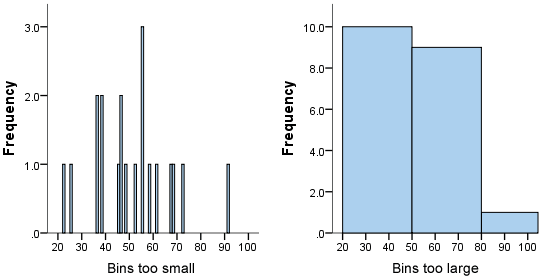

- **Regression**: involves finding the “best” line to fit two attributes (or variables) so
that one attribute can be used to predict the other (ecah value on the line is the average of all values has the same x-axis value).

To check if two variable have a linear relation, we use scatter plot:

In [ ]:
fig = px.scatter(df, x="Fare", y="Age", opacity=0.65, color_discrete_sequence=['#00CC96'],
    trendline='ols', trendline_color_override='rgb(27,158,119)')
fig.update_layout(**layout_options)
fig.show()

You should be at this level expert in regression and you know that the above regression line is wrong and there is no relation between age and fare, but do you know about residuals plot?

Errors/residuals = real reponse variable values (y) - predicted reponse variable values

Residual plot is simply the scatter plot between residuals and the predictor (x) values that show you if your work is right, the residuals should be random when your work is right, otherwise, the relation between the variable if not linear (plotting a histogram of the residuals and make sure it looks normally distributed).

- Some outliers detection methods help in detect noise like: antoencoder, SVD, ...etc

### Fix Noisy labels

- **Distance-based methods**:

  **KNN - k-nearest neighbors** algorithm: is a non-parametric, supervised learning classifier,  meaning that no prior information about the distribution is needed or assumed for the algorithm. Meaning that KNN only relies on the data, to be more exact, the training data.

  **Steps**:

  - Select the number K of the neighbors
  - Calculate the Euclidean distance of K number of neighbors
  - Take the K nearest neighbors as per the calculated Euclidean distance.
  - Among these k neighbors, count the number of the data points in each category.
  - Assign the new data points to that category for which the number of the neighbor is maximum (**majority votes**).

  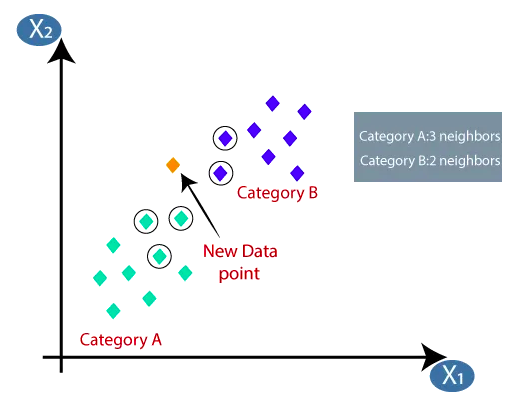

For now let's use some obvious correleted features to predict incosistent survived classes using KNN, and later on we talk about how to choose the best features.

In [ ]:
X = pd.get_dummies(df[~df['Survived'].isnull()][['Fare', 'Pclass', 'Age', 'Sex', 'SibSp',	'Parch']], dtype=int).values
y = df[~df['Survived'].isnull()]['Survived'].astype('int').values

In [ ]:
k = 6
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, indices = nbrs.kneighbors(X)

In [ ]:
indices

array([[  0, 320, 212,  60, 553, 243],
       [  1, 540, 665, 218, 741, 558],
       [  2, 315, 216, 246, 729, 628],
       ...,
       [888, 651, 409, 229, 485, 136],
       [889, 607, 580, 782, 793, 270],
       [828, 890, 107, 569, 519, 636]])

In [ ]:
votings = np.array([np.sum(y[indices[:, 1:][i]]) for i in range(indices.shape[0])])
majority_class = np.where(votings < 3, 0, 1)

In [ ]:
temp = df[~df['Survived'].isnull()].copy()
temp['KNN Survived'] = majority_class

temp[temp['KNN Survived'] != temp['Survived']]

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,KNN Survived
2,2,3,1.0,3,Miss,female,26.0,0,0,STON/O2. 3101282,7.9250,5,S,0
6,6,7,0.0,1,Mr,male,54.0,0,0,17463,51.8625,E,S,1
7,7,8,0.0,3,Master,male,2.0,3,1,349909,21.0750,5,S,1
9,9,10,1.0,2,Mrs,female,14.0,1,0,237736,30.0708,3,C,0
11,11,12,1.0,1,Miss,female,58.0,0,0,113783,26.5500,C,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
854,854,855,0.0,2,Mrs,female,44.0,1,0,244252,26.0000,5,S,1
855,855,856,1.0,3,Mrs,female,18.0,0,1,392091,9.3500,5,S,0
861,861,862,0.0,2,Mr,male,21.0,1,0,28134,11.5000,5,S,1
880,880,881,1.0,2,Mrs,female,25.0,0,1,230433,26.0000,5,S,0


Wrong labels could be exist in the previous rows, but as you see there are many rows and it's very hard to review all manually (or by a domain expert), in addition, the distance assumption is not necessary correct, and features could not be the best ones.

**Problems**:
- The distance assumption is not necessary correct.
- KNN is sensitive to noisy data.
- The model is the data itself.
- Computational expense, slow speed, memory and storage issues for large datasets.
- Sensitivity to the choice of k and the distance metric.
- Susceptibility to the curse of dimensionality.

- **Model-based method**:

1. Train any ML model on a clean (noise free) subset of your data, then use the model to predict rest of the data labels, the instance is a noise when there is disagreement between model prediction and the instance label.

2. Use robust model:
- Preprocess the data and train a model g on the dataset (x, y).
- Use the trained model g to re-classify x, and obtain
g(x) = ˜y.
- Return all x with ˜y$\neq$y as instances with noisy labels.

3. **Confident Learning**: the most popular method

- The assumption: is the label noise transitions
are data-independent, i.e., $p(y˜|y^*; x) = p(y˜|y^∗)$.

- The  goal: is
to estimate every $p(y˜, y^*)$ as a matrix $Q_{y~,y^*}$ and use Q to find all mislabeled examples
x in dataset X where  $˜y\neq y^*$
- The input: the out-of-sample predicted
probabilities $P_{k,i}$ and  the noisy labels $y˜_k$.

- How?

  Train any model that produces a mapping
θ : x → probabilities can be used (e.g. neural nets with a softmax output, naive Bayes,
logistic regression, etc.) on subset of the noisy training instances (change the subset each time using cross-validation).

  Predict the rest subset (out-of-sample data) labels to find confident joint $C_{y~,y^*}$ that estimates $X_{y˜=i,y^∗=j}$ , the set of examples with noisy label i that actually have true label j.

  \begin{align}
  C_{y~,y^*}[i][j] = |Xˆ_{y˜=i,y^∗=j}|
  \end{align}
  where $Xˆ_{y˜=i,y^∗=j}$ is the set of examples x labeled y˜=i with large enough $p(y˜=j; x, θ)$ to likely belong to class $y^∗=j$, determined by a per-class threshold, $t_j$.

  \begin{align}
  Xˆ_{y˜=i,y^∗=j} = \{x ∈ X_{y˜=i}: p(y`=j; x, θ) ≥ t_j\}
  \end{align}

  The threshold $t_j$ is the expected (average) self-confidence for each class:

  \begin{align}
  t_j = \frac{1}{|X_{y˜=j}|} \sum_{x \in X_{y˜=j}}p(y` = j; x, θ)
  \end{align}

  C is then normalized to obtain an estimation of the error matrix Q:

  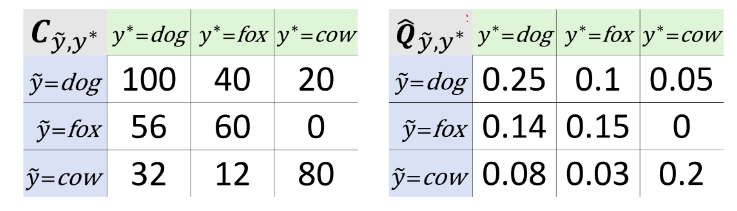

  For each class i ∈ [m], select the n.Q[i][j] examples with lowest self-confidence $p(y~ = i; x)$
  
  Paper: [Confident Learning:
Estimating Uncertainty in Dataset Labels](https://arxiv.org/pdf/1911.00068.pdf) is implemmented in cleanlab library.


In [ ]:
from cleanlab.classification import CleanLearning
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier()
# This works with any sklearn-compatible model
label_issues_info = CleanLearning(clf=clf).find_label_issues(X, y)
label_issues_info

,is_label_issue,label_quality,given_label,predicted_label
0,False,0.915937,0,0
1,False,0.962464,1,1
2,False,0.579925,1,1
3,False,0.989473,1,1
4,False,0.813512,0,0
...,...,...,...,...
886,False,0.739665,0,0
887,False,0.984574,1,1
888,False,0.675567,0,0
889,False,0.461005,1,0


In [ ]:
label_issues_info[label_issues_info['is_label_issue']]

,is_label_issue,label_quality,given_label,predicted_label
14,True,0.264360,0,1
21,True,0.120018,1,0
23,True,0.121404,1,0
25,True,0.030859,1,0
41,True,0.073067,0,1
...,...,...,...,...
854,True,0.107098,0,1
855,True,0.260568,1,0
857,True,0.268142,1,0
867,True,0.359374,0,1


The related instances need to check manually by a an expert.

The problem is still active research area, let's introduce one of the recent work in this area:

Combating Noisy Labels with Sample Selection by Mining High-Discrepancy Examples (2023):

  Assumption: clean labels are the majority in a noisy class, and deep networks learn patterns first, they would first memorize training data of clean labels with the assumption that clean labels are of the majority in a noisy class. Small loss training examples can thus be regarded as clean examples with high probability.

  Method:
  - Train two deep neural networks on the dataset, and for each example $(x_i, y˜_i)$, we get prediction probabilities over c class:

  $$p_1(x_i) = [p_1^1(x_i), p_1^2(x_i), ... , p_1^c(xi)]$$ $$p_2(x_i) = [p_2^1(x_i), p_2^2(x_i), ... , p_2^c(xi)] $$

  - Get the cross-entropy loss (classification loss) for the instance $x_i$:
  $$Loss_c = − \sum_{j=1}^cy~_i^j . log\ p_{1,2}^j(x_i)$$

  - Calculate the divergence between the two probability distributions using  Kullback-Leibler (KL) to measure the difference of the two networks’ predictions p1(xi) and p2(xi):

  $$KL(p|q) = \sum_{x \in X}p(x).log(\frac{p(x)}{q(x)})$$

  $$Discrepancy\ loss:\ Loss_D= 1/2KL(p_1|p_2) + 1/2KL(p_2|p_1)$$

  - Define the joint loss for sample selection:

  $$L = loss_C + \alpha. loss_D$$

  where α > 0 is a hyper-parameter to balance the above two terms.

- Select the examples with smaller joint losses as clean examples.












Note: other errors types:

- Inconsistent data representations (e.g., “2010/12/25” and “25/12/2010” for date).

- **Field overloading**: when two or more data elements are coupled into one field. For example:
  - Standard state codes (AL for Alabama, etc) provide a mental shortcut to the state name. If a code combined states, regions, and counties, then it wouldn’t be obvious whether AL were Alabama or Alameda County.
  - Discount amount field alone is not helping to know quantity that must be purchased to get a discount.

  Solution: **Parsing** is a process in which individual data elements are located and identified in source systems and then these elements are separated into target files. For example, parsing of name into the First name, Middle name, and Last name or parsing the address into a street name, city, state, and country.

## Outlier Detection

What is an **outlier**?
An outlier is a data object that deviates significantly from the rest of the objects, as if it were generated by a different mechanism. we may refer to data objects that are not outliers as **“normal”** or expected data. Similarly, we may refer to outliers as **“abnormal”** data.

`Outliers can significantly skew your results, leading to misleading conclusions.`

**Outlier detection**:
Outlier detection (also known as **anomaly detection**) is the process of finding data objects with behaviors that are very different from expectation. Such objects are called outliers or anomalies.

**Note**: *Outlier detection and clustering analysis are two highly related tasks.*


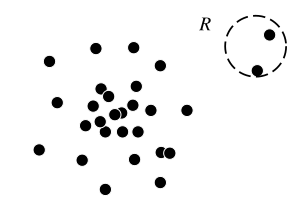



**Example**:

To protect your customers from credit card fraud, you pay special attention to card usages that are rather different from typical cases.
For example, if a purchase amount is much bigger than usual for a card owner, and if the purchase occurs far from the owner’s resident city, then the purchase is suspicious. You want to detect such transactions as soon as they occur and contact the card owner for verification.
Most credit card transactions are normal. However, if a credit card is stolen, its transaction pattern usually changes dramatically—the locations of purchases and the items purchased are often very different from those of the authentic card owner and other customers. An essential idea behind credit card fraud detection is to identify those transactions that are very different from the norm.

**Outliers** vs **noise**:
Outliers are different from noisy data. noise is a random error or variance in a measured variable. In general, noise is not interesting in data analysis.

For example, in credit card fraud detection, a customer’s purchase behavior can be modeled as a random variable. A customer may generate some “noisy transactions” that may seem like “random errors” or “variance,” such as by buying a bigger lunch one day, or having one more cup of coffee than usual.
Such transactions should not be treated as outliers; otherwise, the credit card company would incur heavy costs from verifying that many transactions. The company may also lose customers by bothering them with multiple false alarms.

Outliers are interesting because they are suspected of not being generated by the same mechanism as the rest of the data.

As in many other data analysis and data mining tasks, `noise should be
removed before outlier detection.`


**Types of outliers**:
- **Global outliers**: the simplest type of outliers. Most outlier detection methods are aimed at finding global outliers.

  *Example*: intrusion detection: If the communication behavior of a computer is very different from the normal patterns (e.g., a large number of packages is broadcast in a short time), this behavior may be considered as a global outlier.

- **Local outliers**: it deviates significantly with respect to a specific context of the object. Contextual outliers are also known as conditional outliers because they are conditional on the selected context. Therefore, in contextual outlier detection, the context has to be specified as part of the problem definition.

  *Example*: “The temperature today is 28◦ C. Is it exceptional (i.e., an outlier)?” It depends, for example, on the time and location! If it is winter in Toronto, yes, it is an outlier.

  Consider customers who use more than 90% of their credit limit. If one such customer is viewed as belonging to a group of customers with low credit limits, then such behavior may not be considered an outlier. However, similar behavior of customers from a high-income group may be considered outliers if their balance often exceeds their credit limit.

- **Collective outliers**: if the objects as a whole deviate significantly from the entire data set. Importantly, the individual data objects may not be outliers.

  *Example*: If the shipment of an order is delayed, it may not be considered an outlier because, statistically, delays occur from time to time. However, you have to pay attention if 100 orders are delayed on a single day. Those 100 orders as a whole form an outlier.

  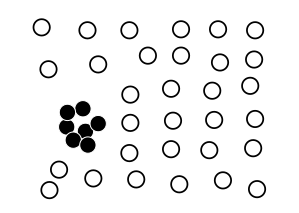

`We need background knowledge of the relationship among data objects`

**Important**: noise and missing data may “hide” outliers and reduce the effectiveness of outlier
detection—an outlier may appear **“disguised”** as a noisy point, and an outlier detection method may mistakenly identify a noisy point as an outlier.




**Methods**:

- Supervised methods
Can we handle it with a binary classifier?
The two classes (i.e., normal objects vs. outliers) are imbalanced. That is, the population of outliers is typically much smaller than that of normal objects.
The lack of outlier samples can limit the capability of the constructed classifiers. To tackle these problems, some methods “make up” artificial outliers.

- Unsupervised methods:
Unsupervised outlier detection methods make an implicit assumption: The normal objects are somewhat “clustered.”
This assumption may not be true all the time. Example: collective outliers.



### Statistical Approaches
Statistical methods for outlier detection make assumptions about data normality. They assume that the normal objects in a data set are generated by a stochastic process (e.g., a generative model). Consequently, normal objects occur in the regions of high probability for the stochastic model, and objects in the regions of low probability are outliers.

#### Parametric Methods

Assumes that the normal data objects are generated by a parametric distribution with a finite number of parameters. A parametric distribution is based on a mathematical function whose shape and range is determined by one or more distribution parameters.

##### Normal Distribution and Z-Score

We can then learn the parameters of the normal (i.e., Gaussian) distribution from the input data and identify the points with low probability as outliers by **the 3σ rule**. The 3σ rule is a straightforward and effective outlier detection method based on statistical principles. It labels any object as an outlier if its distance from the mean of the estimated distribution is more than 3 times the standard deviation (3σ):
- Calculate data mean and std.
- Calculate each point distance from the mean.
- We know that the μ ± 3σ region contains 99.7% data under the assumption of normal distribution, so the value with probability less than 0.15% (its distance from the mean bigger than 3 std) can be identified as an outlier.

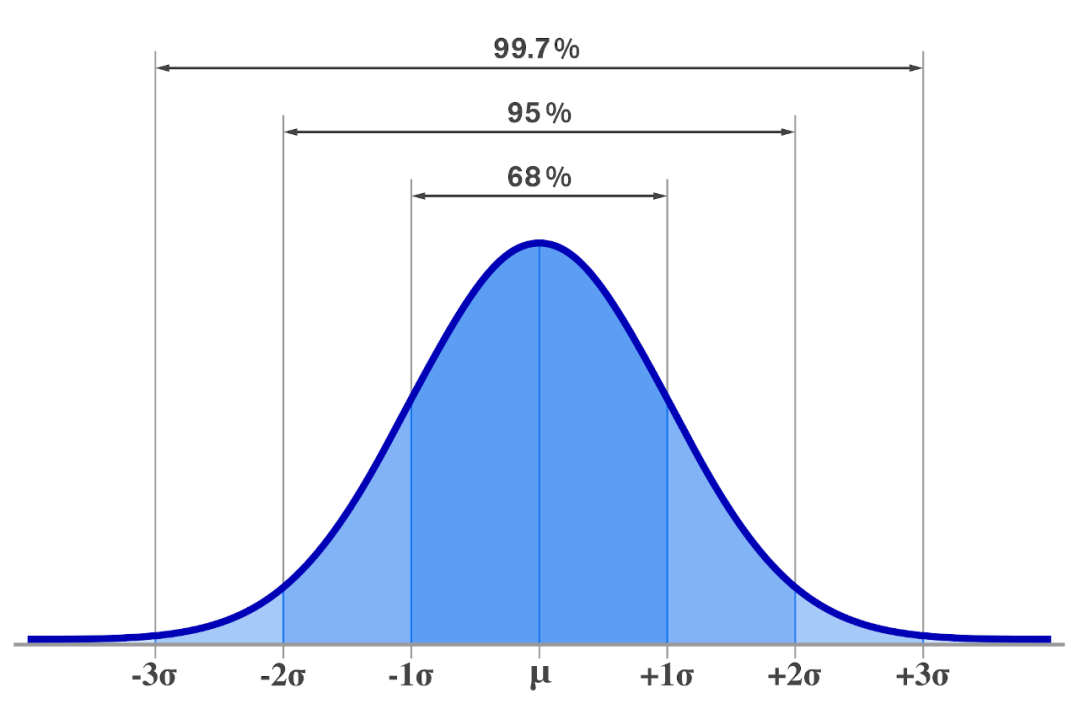


In [ ]:
def detect_outliers(df, column):
  mean = df[column].mean()
  std = df[column].std()
  upper_bound = mean + 3 * std
  lower_bound = mean - 3 * std
  return df[(df[column] > upper_bound) | (df[column] < lower_bound)][column]

In [ ]:
detect_outliers(df, 'Fare')

27      263.0000
88      263.0000
118     247.5208
258     512.3292
299     247.5208
311     262.3750
341     263.0000
377     211.5000
380     227.5250
438     263.0000
527     221.7792
557     227.5250
679     512.3292
689     211.3375
700     227.5250
716     227.5250
730     211.3375
737     512.3292
742     262.3750
779     211.3375
915     262.3750
944     263.0000
950     262.3750
955     262.3750
960     263.0000
965     211.5000
966     211.5000
972     221.7792
1005    221.7792
1033    262.3750
1047    221.7792
1075    247.5208
1093    227.5250
1109    211.5000
1215    211.3375
1234    512.3292
1266    262.3750
1298    211.5000
Name: Fare, dtype: float64

We can handle it in another way:

**Z-score**: how many standard deviations the value is away from the mean (also known as **Grubb’s test**).

It corresponds to a scaled and translated random variable with a mean 0 and standard deviation of 1.
For each object x in a data set, we define a z-score as:

$$ z = \frac{|x - μ|}{σ}$$

An object x is an outlier if z > 3.



In [ ]:
def detect_outliers(df, column):
  mean = df[column].mean()
  std = df[column].std()
  df[column + '_z_scores'] = df[column].apply(lambda x: abs(x - mean) / std)
  return df[df[column + '_z_scores'] > 3][column]

In [ ]:
detect_outliers(df, 'Fare')

27      263.0000
88      263.0000
118     247.5208
258     512.3292
299     247.5208
311     262.3750
341     263.0000
377     211.5000
380     227.5250
438     263.0000
527     221.7792
557     227.5250
679     512.3292
689     211.3375
700     227.5250
716     227.5250
730     211.3375
737     512.3292
742     262.3750
779     211.3375
915     262.3750
944     263.0000
950     262.3750
955     262.3750
960     263.0000
965     211.5000
966     211.5000
972     221.7792
1005    221.7792
1033    262.3750
1047    221.7792
1075    247.5208
1093    227.5250
1109    211.5000
1215    211.3375
1234    512.3292
1266    262.3750
1298    211.5000
Name: Fare, dtype: float64

In [ ]:
df['fare_outlier'] = detect_outliers(df, 'Fare')
df['fare_outlier'] = df['fare_outlier'].apply(lambda x: 0 if np.isnan(x) else 1)

In [ ]:
def plot_anomalies(df, column, predictions_column):
  fig = go.Figure()
  fig.add_trace(go.Box(y=df[df[predictions_column] == 1][column], boxpoints = 'all', pointpos = 0,
                      name=column,
                      marker = dict(color = 'MediumPurple', line=dict(width=2), size=12),
                      line = dict(color = 'rgba(0,0,0,0)'),
                      fillcolor = 'rgba(0,0,0,0)'
  ))

  fig.add_trace(go.Box(y=df[df[predictions_column] == 0][column], boxpoints = 'all', pointpos = 0,
                      name=column,
                      marker = dict(color = 'LightSkyBlue',  line=dict(width=2), size=12),
                      line = dict(color = 'rgba(0,0,0,0)'),
                      fillcolor = 'rgba(0,0,0,0)'
  ))
  fig.update_layout(**layout_options)
  fig.show()

In [ ]:
plot_anomalies(df, 'Fare', 'fare_outlier')

**Problems**:

- Mean and std influenced by the outliers.
- If the wrong model is chosen, then an object can be erroneously identiﬁed as an outlier. For example, the data may be modeled as coming from a Gaussian distribution, but may actually come from a distribution that has a higher probability (than the Gaussian distribution) of having values far from the mean. Statistical distributions with this type of behavior are common in practice and are known as **heavy-tailed** distributions, and asymmetric distributions may not even have a tail at one end of the distribution.

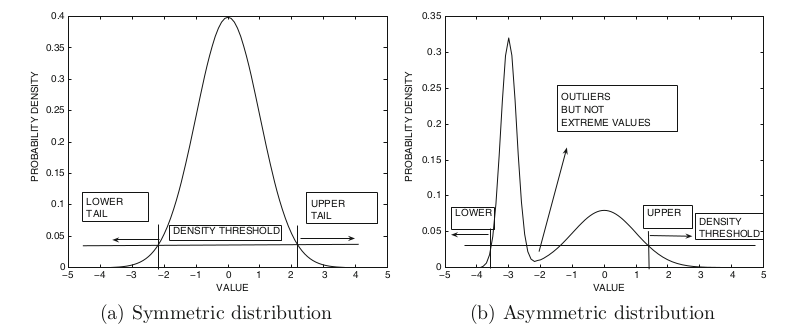

- When a large number of data samples is available, the mean and standard deviation may be estimated very accurately, but this is not always the case (we use **student t-distribution with n degrees of freedom** instead of normal distribution).

The t-distribution is similar to the normal distribution with its bell shape but has heavier tails. It is used for estimating population parameters for small sample sizes or unknown variances. The probability density function of the t-distribution is different:

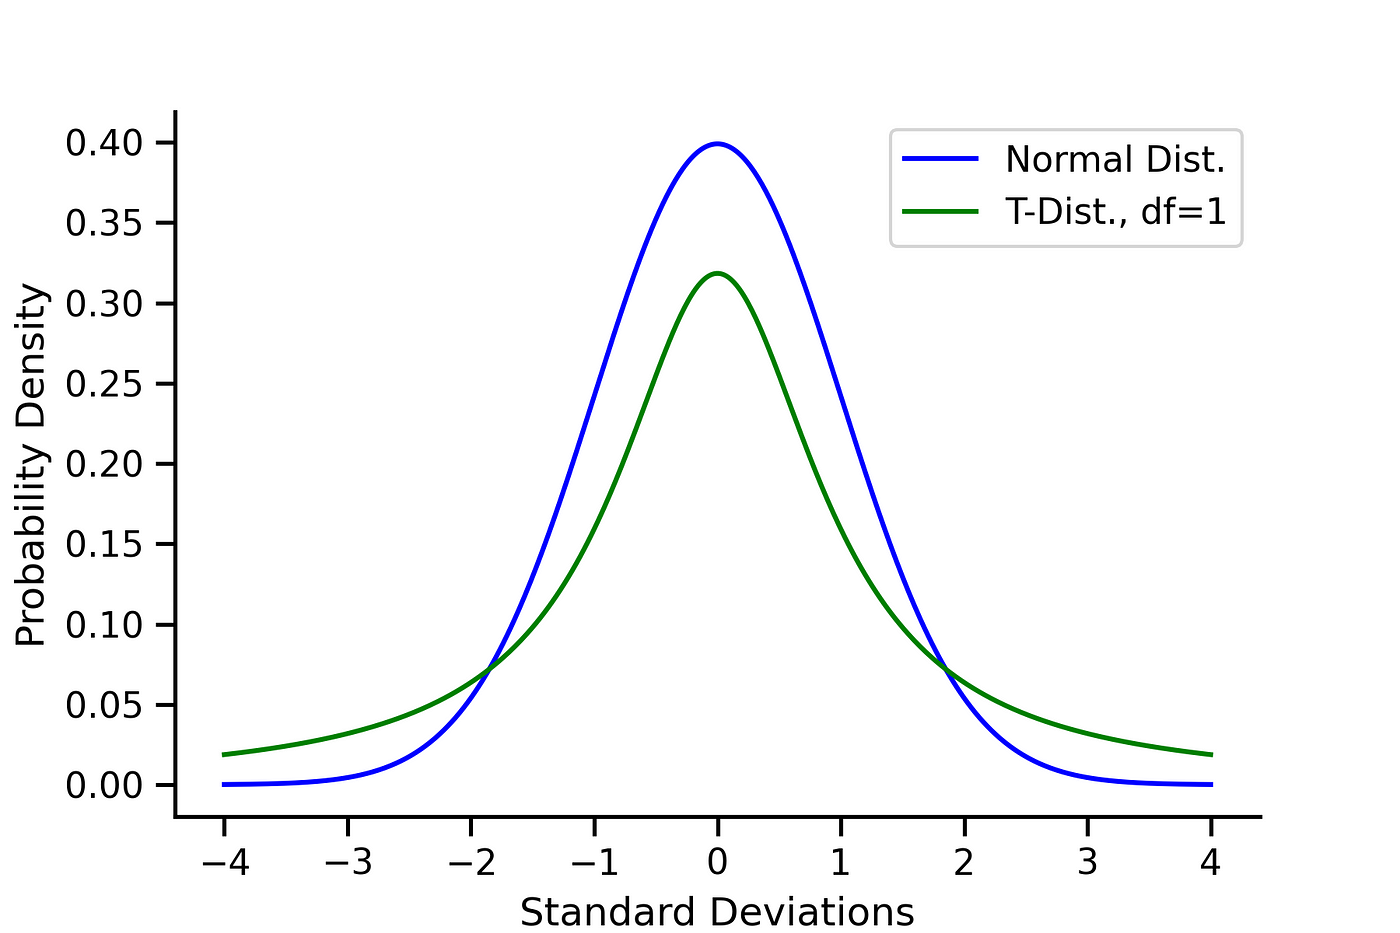

The freedom degree is calculated as one less than the sample size in most situations, has a large impact on the shape of the distribution at lower values.

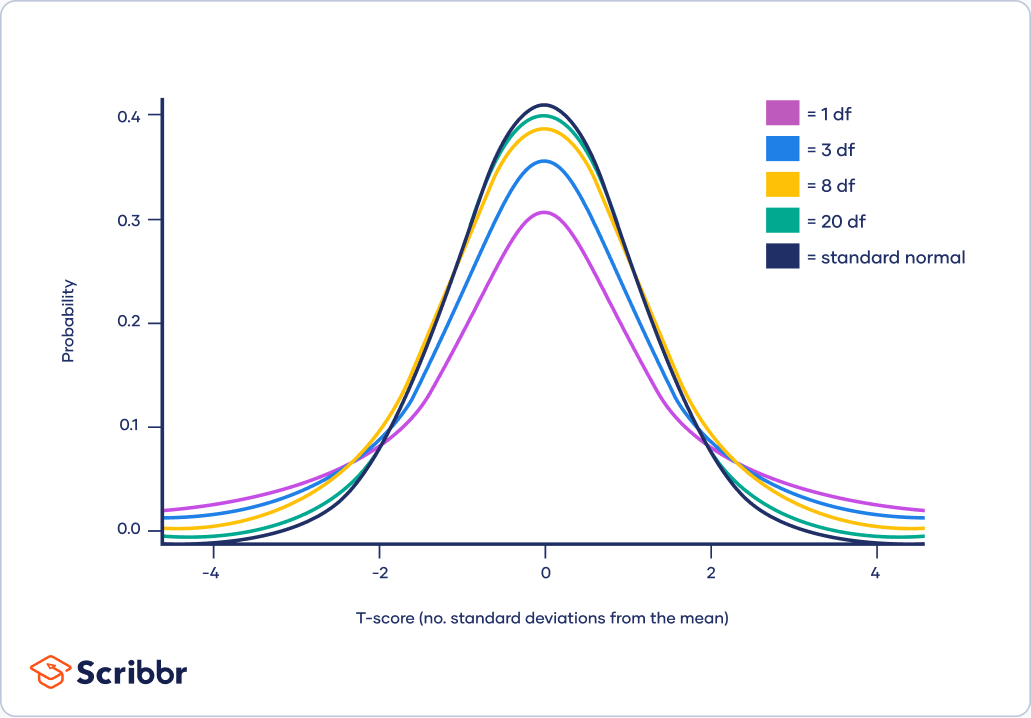

When df=1 the distribution is called **Cauchy** distribution, when df is huge the distribution become normal distribution.



##### 2. Interquartile Range (IQR) Method

Any object that is outside the region  Q1 − 1.5 × IQR and Q3 + 1.5 × IQR  is treated as an outlier because the region between Q1 − 1.5 × IQR and Q3 + 1.5 × IQR contains 99.3% of the objects (as 3σ rule).


In [ ]:
fig = go.Figure()
fig.add_trace(go.Box(
    y=df['Fare'],
    name="Fare",
  #  marker=dict(
  #       color='rgb(7,40,89)',
  #       outliercolor='rgba(219, 64, 82, 0.6)',
  #       line=dict(
  #           outliercolor='rgba(219, 64, 82, 0.6)',
  #           outlierwidth=2)),
  #   line_color='rgb(7,40,89)'
))
fig.update_layout(**layout_options)
fig.show()

In [ ]:
def IQR(df, column):
    quartile1 = df[column].quantile(0.25)
    quartile3 = df[column].quantile(0.75)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return df[(df[column] > up_limit) | (df[column] < low_limit)][column]

In [ ]:
IQR(df, 'Fare')

1        71.2833
27      263.0000
31      146.5208
34       82.1708
52       76.7292
          ...   
1288     79.2000
1291    164.8667
1298    211.5000
1302     90.0000
1305    108.9000
Name: Fare, Length: 171, dtype: float64

#### Nonparametric Methods

Does not assume an a priori statistical model with a finite number of parameters. Instead, a nonparametric method tries to determine the model from the input data.


##### 1. Median Absolute Deviation (MAD)

$$ diff(x_i) = |x_i - median(X)|$$<br>
$$ score(x_i) = \frac{diff(x_i)}{median(diff(X))}$$

If score(x) > threshold, then x is an outlier.


In [ ]:
from pyod.models.mad import MAD

model = MAD()

predictions = model.fit_predict(df['Fare'].to_numpy().reshape(-1, 1))
predictions

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:86: FutureWarning:

Function fit_predict is deprecated



array([0, 1, 0, ..., 0, 0, 0])

In [ ]:
model.decision_scores_

array([0.70380825, 5.55187103, 0.63786469, ..., 0.70380825, 0.62565292,
       0.77218439])

In [ ]:
df['fare_outlier'] = predictions

In [ ]:
plot_anomalies(df, 'Fare', 'fare_outlier')

By default the threshold=3.5. Let's change the threshold:

In [ ]:
model.decision_scores_[np.where(model.decision_scores_ > 3.5)]

array([ 5.55187103,  3.77546886,  3.65457234, 24.28147245, 12.90213518,
        6.61551616,  3.66800529,  6.08390364,  4.64291482,  6.40344169,
        6.74292888,  5.76842967,  4.10721868, 24.28147245,  4.56434918,
        4.77764483,  6.13844629,  3.66800529, 22.76924505,  5.76842967,
        6.13844629,  3.77546886,  6.32528636,  5.09433998,  4.58429833,
        5.38253775,  3.96108776,  4.10721868,  5.38253775, 12.90213518,
        5.38253775,  9.65421477,  6.04116244,  7.38038326,  6.74292888,
        7.38038326,  3.72214739,  6.32528636,  7.03845371, 48.63947851,
        6.36924873, 13.58029871, 11.83849004,  6.20397953,  6.29109341,
        7.48581479, 13.39345863, 22.76924505, 13.39345863,  9.42055965,
        9.22680283,  4.14955933,  6.71198914, 24.2204136 , 14.69442242,
       11.72777325,  5.38253775, 11.83849004,  4.25213819, 13.58029871,
       11.64473322,  5.09433998, 11.72777325, 24.28147245,  3.96108776,
        5.93939444,  5.35811421,  4.00423927, 11.83849004,  6.61

In [ ]:
model = MAD(threshold=8)
predictions = model.fit_predict(df['Fare'].to_numpy().reshape(-1, 1))
df['fare_outlier'] = predictions
plot_anomalies(df, 'Fare', 'fare_outlier')

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:86: FutureWarning:

Function fit_predict is deprecated



##### 2. Histogram

- Calculate the bin percentage (e.g., the frequency of values in the bin)
- Assign an outlier-ness score to the bin: 1/percentage

The bigger score the point is more likely to be an outlier.


In [ ]:
fig = px.histogram(df, x='Fare')
fig.update_layout(**layout_options)
fig.show()

In [ ]:
fig = px.histogram(df, x='Fare', nbins=20)
fig.update_layout(**layout_options)
fig.show()

In [ ]:
bin = 20
df['bin'] = pd.cut(df['Fare'], bin)

# Calculate the mean within each bin
df['fare_bin_percentage'] = 1 / ((df.groupby('bin')['bin'].transform('count') * 100 )/ df.shape[0])
df.head()

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Fare_z_scores,fare_outlier,bin,fare_bin_percentage
0,0,1,0.0,3,Mr,male,22.0,1,0,A/5 21171,7.2500,5,S,0.503079,0,"(-0.512, 25.616]",0.015809
1,1,2,1.0,1,Mrs,female,38.0,1,0,PC 17599,71.2833,C,C,0.734475,0,"(51.233, 76.849]",0.128333
2,2,3,1.0,3,Miss,female,26.0,0,0,STON/O2. 3101282,7.9250,5,S,0.490033,0,"(-0.512, 25.616]",0.015809
3,3,4,1.0,1,Mrs,female,35.0,1,0,113803,53.1000,C,S,0.383052,0,"(51.233, 76.849]",0.128333
4,4,5,0.0,3,Mr,male,35.0,0,0,373450,8.0500,5,S,0.487617,0,"(-0.512, 25.616]",0.015809


In [ ]:
df['fare_bin_percentage'].unique()

array([0.01580918, 0.12833333, 0.05386831, 1.00692308, 0.5236    ,
       0.25173077, 4.36333333, 0.77      , 3.2725    , 0.72722222])

In [ ]:
df[df['fare_bin_percentage'] > 1]['Fare']

27      263.0000
88      263.0000
118     247.5208
258     512.3292
299     247.5208
311     262.3750
318     164.8667
341     263.0000
438     263.0000
679     512.3292
737     512.3292
742     262.3750
856     164.8667
915     262.3750
944     263.0000
950     262.3750
955     262.3750
960     263.0000
1033    262.3750
1075    247.5208
1108    164.8667
1234    512.3292
1266    262.3750
1291    164.8667
Name: Fare, dtype: float64

**Problems**:

Hard to choose an appropriate bin size. On the one hand, if the bin size is set too small, many normal objects may end up in empty or rare bins and thus be misidentified as outliers. This leads to a high false positive rate and low precision. On the other hand, if the bin size is set too high, outlier objects may infiltrate into some frequent bins and thus be **“disguised”** as normal.

To overcome this problem, we can adopt kernel density estimation to estimate the probability density distribution of the data.



##### 3. Kernel Density Estimation (KDE)

As you know, a kernel function is modeling the influence of a sample point within its neighborhood.

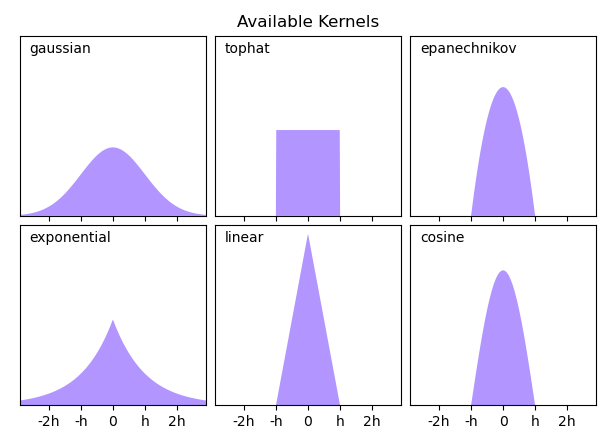

*Example*:

Let’s say, we have marks obtained by six students in a subject. We are going to construct a kernel at each data point using **Gaussian kernel** function.

$marks \ are \ x_i = \{65, 75, 67, 79, 81, 91\}\ where
\ x_1 = 65, x_2 = 75 … x_6 = 91$.

Three inputs are required to develop a kernel curve around a data point. They are:
- The observation data point which is $x_i$
- The value of h Bandwidth
- A linearly spaced series of data points which houses the observed data points where K values are estimated. $X_j = \{50,51,52 …. 99\}$.

Steps:
- Extract all $x_i$ values from all $x_j$ values and normalize them by h:

$$ \frac{x_j - x_i}{h}$$

- Apply kernal function on the results, let's consider we applyied gussian function:

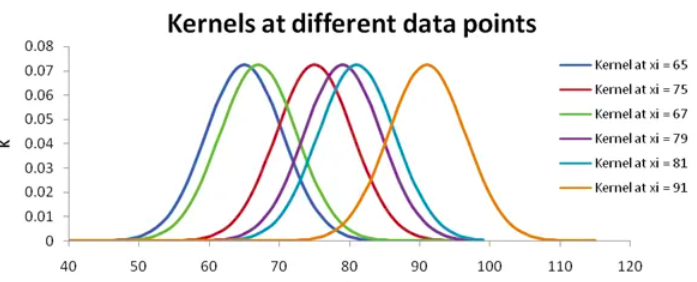

- KDE for the whole data set is obtained by adding all values for each $X_j$. The sum is then normalized by the number of data points, which is six in this example:

  $$f_h(x_j) = \frac{1}{n.h}\sum_{i=0}^{n}k\frac{x_j - x_i}{h}$$

  Normalization is done to bring the area under the KDE curve to one.

  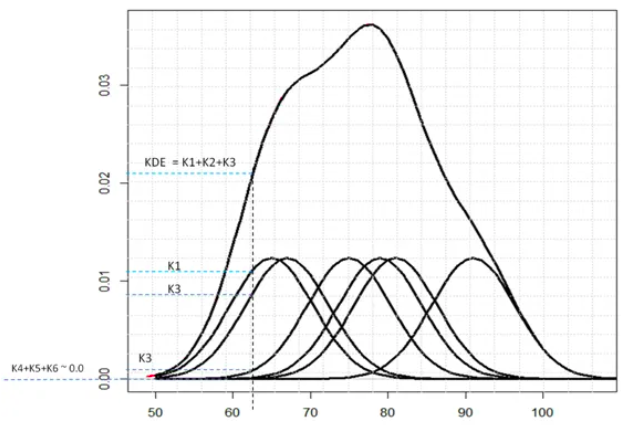

Bandwidth serving as a smoothing parameter:

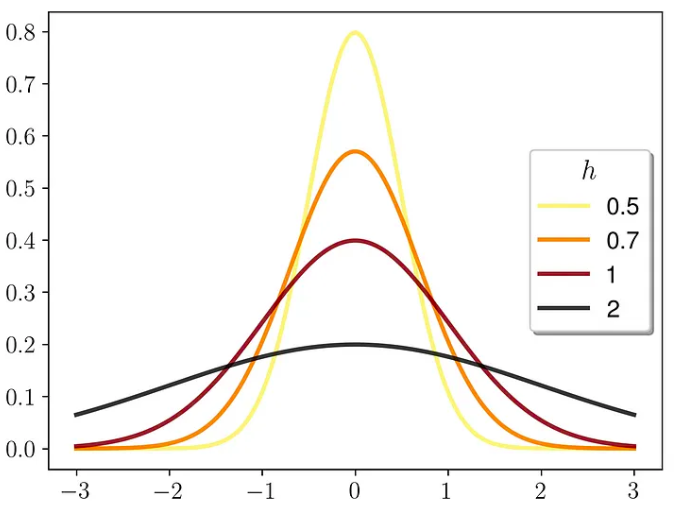

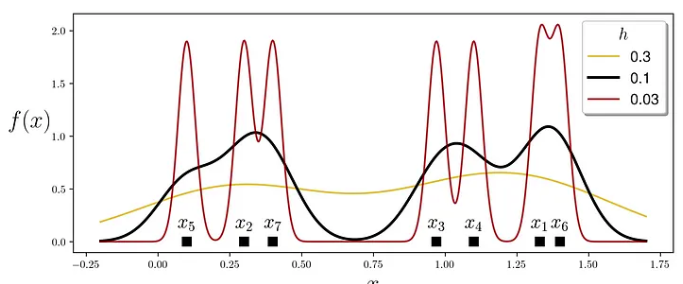


KDE for the whole data set is obtained by adding all values for each $X_j$. The sum is then normalized by dividing the number of data points, which is $x_i$ in this example. Normalization is done to bring the area under the KDE curve to one.

If f(x) is high, then the object is likely normal. Otherwise, x is likely an outlier.

**Problem**:

The computational cost: kernel density estimation cost can be up to quadratic.

Pyod kde returns the negative log probabilities, The higher score, the more abnormal.

One benefit of taking the negative logs of the probabilities is that a lower probability is converted to a higher negative log value. Thus, the rare items with low probabilities are given higher anomaly scores.



In [ ]:
from pyod.models.kde import KDE

model = KDE(bandwidth=0.7)
predictions = model.fit_predict(df['Fare'].to_numpy().reshape(-1, 1))
predictions

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:86: FutureWarning:

Function fit_predict is deprecated



array([0, 1, 0, ..., 0, 0, 0])

In [ ]:
df['fare_outlier'] = predictions

In [ ]:
plot_anomalies(df, 'Fare', 'fare_outlier')

In [ ]:
Xj = np.linspace(0, 600, 1000)
logprob = model.kde_.score_samples(Xj[:, np.newaxis])

fig = px.line(x=Xj, y=np.exp(logprob))
fig.update_layout(**layout_options)
fig.show()

##### 4. Angle-based Method (ABOD)

Assumptions:
- A normal point makes angles with any other two data points varies a lot as you choose different data points.
- The angle an anomaly makes with other data points doesn’t vary much as you choose different data points.


Steps:
- For each data point, determine the angle it makes with all pairs of other data points (arccosine of the normalized dot product).
- Calculate angles variance.
- Points for which the variance is below a predetermined threshold are anomalies.

$$ ABOD(o) = (o) = VAR_{x,y∈D,x \neq o,y \neq o} = \frac{ox^→.oy^→}{dist(o,x)^2.dist(o, y)^2}$$


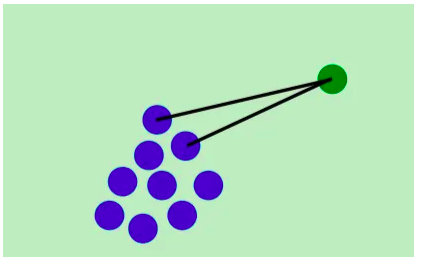

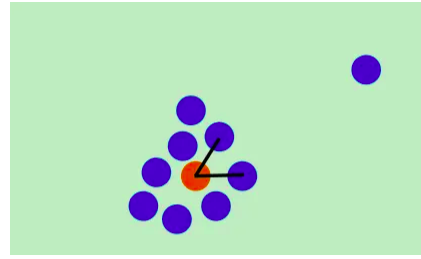



In pyod ABOD class: for an observation, the variance of its weighted cosine scores to all neighbors could be viewed as the outlying score.

Two version of ABOD are supported:

- Fast ABOD: use k nearest neighbors to approximate.
- Original ABOD: consider all training points with high time complexity at O(n^3).

In [ ]:
from pyod.models.abod import ABOD

model = ABOD(method='fast', n_neighbors=100)
predictions = model.fit_predict(df['Fare'].to_numpy().reshape(-1, 1))
predictions

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:86: FutureWarning:

Function fit_predict is deprecated



array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
df['fare_outlier'] = predictions

In [ ]:
plot_anomalies(df, 'Fare', 'fare_outlier')

**Problems**:

Angle-based is very costly.

##### 5. Empirical Cumulative Distribution Functions (ECOD)

(2021)

- No hyperparameters
- Can be applied to multivariate "cumulative" probabilities.

The probabilities that accumulate as we move from left to right along the x-axis in our probability distribution $F(x_i) = p(X < x_i)$.

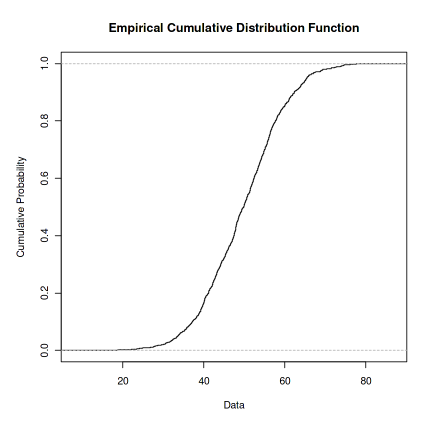

ECOD uses information about the distribution of the data to determine where data is less likely (low-density) and thus more outlierly. Specifically, ECOD estimates a empirical cumulative distribution function (ECDF) for each variable of the data separately. To generate an outlier score for an observation, ECOD computes the tail probability for each variable using the univariate ECDFs and multiplies them together.

For each value $x_i$ for the variable x (if data is multivariate we repeat for each feature in the training dataset):
- Estimate the left tail univariate ECDF for the features variable $p(X<x_i)$
- Estimate the right tail univariate ECDF for the features variable $p(X>=x_i)$
- Compute sample skewness coefficient for the variable's distribution:

  To score an observation:
  - O-left = Sum of the negative log of the left-tail probability for every variable.
  - O-right = Sum of the negative log of the right-tail probability for every variable.

  Final outlier score for an observation, simply take the most extreme negative log probability score.

  Score = Max(O-left, O-right)




In [ ]:
fig = px.ecdf(df, x="Fare")
fig.update_layout(**layout_options)
fig.show()

In [ ]:
from pyod.models.ecod import ECOD

model = ECOD()
predictions = model.fit_predict(df['Fare'].to_numpy().reshape(-1, 1))
df['fare_outlier']  = predictions

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:86: FutureWarning:

Function fit_predict is deprecated



In [ ]:
plot_anomalies(df, 'Fare', 'fare_outlier')

### Proximity-based Approaches
Proximity-based approaches assume that the proximity of an outlier object to its nearest neighbors significantly deviates from the proximity of most other objects to their nearest neighbors in the data set.


#### 1. Distance-based Outlier Detection

Let r be a *distance threshold* and p be *neighbors threshold*:

For each point:

For each other point:
- Calculate the its distance from other objects
- Count the number of other objects in the r-neighborhood
- If the count reach p, the inner loop is terminated
- if the inner loop completes for an object , this means that it has less than p neighbors in a radius of r, and thus is an outlier.

The straightforward nested loop approach takes O(n^2) time, but inner loop terminate most of the time.


In [ ]:
def DB(df, column, r, p):
  outliers = []
  for i, row in df.iterrows():
    terminate = False
    neighbors = []
    for _, other_row in df.iterrows():
      if row[column] != other_row[column]:
        dist = abs(row[column] - other_row[column])
        if dist <= r:
          neighbors.append(other_row[column])
        if len(neighbors) == p:
          terminate = True
      if terminate:
        outliers.append(0)
        break
    if not terminate:
      outliers.append(1)
  return outliers

In [ ]:
df['fare_outlier'] = DB(df, 'Fare', 5, 7)

In [ ]:
plot_anomalies(df, 'Fare', 'fare_outlier')

Let's try the same method when taking other variable into account:

PS: the distance between ordinal values M differs form the distance between non ordinal categorical values, where we convert the ordinal value to normalized ranks:
$$ z_i = \frac{r_i-1}{M-1}$$

Pclass is ordinal attribute.

In [ ]:
def DB(df, columns, r, p):
  outliers = []
  for i, row in df.iterrows():
    terminate = False
    neighbors = []
    for j, other_row in df.iterrows():
      if i != j:
        dist = sum([abs(row[column] - other_row[column]) for column in columns]) / len(columns)
        if dist <= r:
          neighbors.append(other_row[columns[0]])
        if len(neighbors) == p:
          terminate = True
      if terminate:
        outliers.append(0)
        break
    if not terminate:
      outliers.append(1)
  return outliers

In [ ]:
df['fare_outlier'] = DB(df, ['Fare', 'Pclass'], 5, 7)

In [ ]:
plot_anomalies(df, 'Fare', 'fare_outlier')

**Problem**:

distance-based outlier detection methods cannot capture local outliers like o1 and o2:

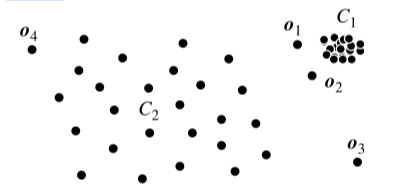


#### 2. Density-based

##### Local Outlier Factor
Steps:
- Get the k-nearest neighbors of the point o
- Calculate the k-distance of a point, which is the maximum distance between o and its neighbors $dist_k(o)$.
- Calculate the k-distance neighborhood of o contains all objects of which the distance to o is not greater than $dist_k(o)$:

  $$N_k(o) = \{o`|dist(o,o`) <= dist_k(o)\}$$

  $N_k(o)$ may contain more than k objects because multiple objects may each be the same distance away from o.
- For two objects, o and $o`$, the reachability distance from $o`$ to o is $dist(o, o`)$ if $dist(o, o`) > dist_k(o)$, and $dist_k(o)$ otherwise. That is:

  $$reachdist(o←o`) = max\{dist_k(o),dist(o,o`)\}$$

- We can define the local reachability density of an object o, as:

$$lrd_k(o) = \frac{||N_k(o)||}{\sum_{o` \in N_k(o)}reachdist(o`←o)}$$

- We define the local outlier factor of an object o as:

  $$LOF_k(o) = \frac{\sum_{o` \in N_k(o)}\frac{lrd_k(o`)}{lrd_k(o)}}{||N_k(o||)} = \sum_{o` \in N_k(o)}lrd_k(o`).\sum_{o` \in N_k(o)}reachdist(o`←o)$$

In other words, the local outlier factor is the average of the ratio of the local reachability density of o and those of o’s k-nearest neighbors. The lower the local reachability density of o (i.e., the smaller the item $\sum_{o`∈ N_k(o)} reachdist_k(o`← o)$) and the higher the local reachability densities of the k-nearest neighbors of o, the higher the LOF value is.


In [ ]:
from pyod.models.lof import LOF

model = LOF(n_neighbors=10) #default n_neighbors=20
predictions = model.fit_predict(df['Fare'].to_numpy().reshape(-1, 1))
df['fare_outlier']  = predictions

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:86: FutureWarning:

Function fit_predict is deprecated



In [ ]:
plot_anomalies(df, 'Fare', 'fare_outlier')

**Problems**:

When a dataset contains clusters with different densities and they are close to each other, it can be shown that LOF fails scoring the instances at the borders of the clusters correctly.

Think in the fare concept, could be any possible local outliers in there?

Try to detect outliers in age variable:

In [ ]:
########################
#####YOUR CODE HERE#####
########################

We will continue the cleaning and other preprocessing phases in the next lecture ...